# JAX based BCDI phase retrieval

In [1]:
import jax
import numpy as np
from jax_model_allfunctions import *
import sys
import time 

sys.path.append('/data/id01/inhouse/bellec/software/sharedipynb/gitlab/bcdi_eb/')
from Global_utilities import *
from Object_utilities import *
from Plot_utilities import *


# Load data

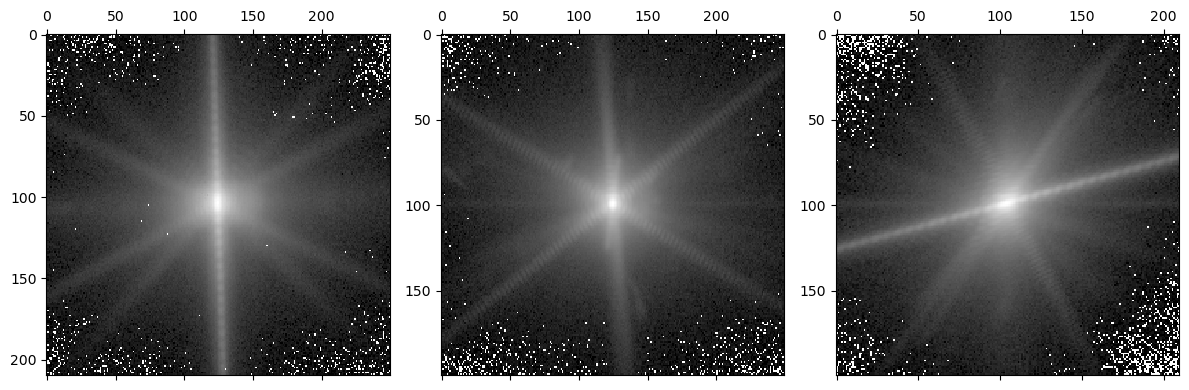

In [21]:
# Iobs = np.load("../ad_github/notebooks/data_prova.npz")["I"].astype(np.float32)
# path = '/data/id01/inhouse/bellec/software/sharedipynb/Matteo/experimental_data/EB_clean_experimental_dataset/EB_random_sizes_clean_experimental_data/'
# index = 16
# files = os.listdir(path)
# filename = path + files[index]
# data = np.load(filename)
# Iobs = data['I']

# path = '/data/projects/id01ml/Codes/PhaseRetrieval/AutoDifferentiation/devels2026/pyramids/preprocessed_data/'
# files = os.listdir(path)
# data = np.load(path + files[1])
# Iobs = data['data']
# key = jax.random.PRNGKey(0)

path = '../../../../spectro_bcdi/hc6500/preprocessed_data_PtNi/dataset_PtNi_BCDI_0055_scan_17.npz'
# path = '/data/bm02/bellec/Local_contacts/2026/20260217_HC6441_Sarrazin/BCDI_reconstructions_for_EB/preprocessed_data_PtPd/dataset_PtPd_BCDI_0019_scan_1.npz'
# path = '/data/bm02/bellec/Local_contacts/2026/20260217_HC6441_Sarrazin/BCDI_reconstructions_for_EB/preprocessed_data_PtPd/dataset_PtPd_BCDI_0020_scan_1test.npz'
# path = '../../../../spectro_bcdi/bm02_feb26/preprocessed_data_PtPd/dataset_PtPd_BCDI_0004_scan_8.npz'

# path = '/data/bm02/bellec/Local_contacts/2026/20260217_HC6441_Sarrazin/BCDI_reconstructions_for_EB/preprocessed_data_PtPd/dataset_PtPd_BCDI_0021_scan_1.npz'
# path = '/data/bm02/bellec/Local_contacts/2026/20260217_HC6441_Sarrazin/BCDI_reconstructions_for_EB/preprocessed_data_PtPd/dataset_PtPd_BCDI_0021_scan_4.npz'
Iobs = np.load(path)['data']

# path= '../../../Paper_phasing/npz_particles/Corentin12.npz'
    
# Iobs = np.load(path)['I']
# path = '../twins/scan229_twin_20260120.npz'
# Iobs = np.load(path)['I']
key = jax.random.PRNGKey(0)

plot_3D_projections(Iobs)

In [22]:
Iobs.shape

(200, 210, 250)

# Solve PR

In [23]:
t0 = time.time()
result = reconstruct(
    key,
    Iobs,
    n_restarts = 32,
    N=64,
    size_factor=4.0,
    eps=0.8,
    alpha=0.0,
    beta=0.01,
    metric="mae",
    phase_type="displacement",
    phase_kwargs={'hkl': [2,2,2]},
    support_type="single",
    # support_kwargs={'M_parts': 3, 'N_per_part': 32},
    optimizer="adam",
    max_steps=2000,
    tol=1e-6,
    memory_size=10,
    learning_rate=0.05,
    grid_shape=None,
)
print(f"done in {time.time() - t0:.1f}s")

done in 629.4s


In [24]:
print("best loss:", float(result.best_loss))
print("steps per restart:", result.all_steps)


best loss: 0.19151753187179565
steps per restart: [2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000
 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000
 2000 2000 2000 2000]


In [25]:
support, amplitude, phase = result.evaluate(Iobs)

modulus = amplitude*support
obj = modulus*phase[0] + 1.0j*modulus*phase[1]


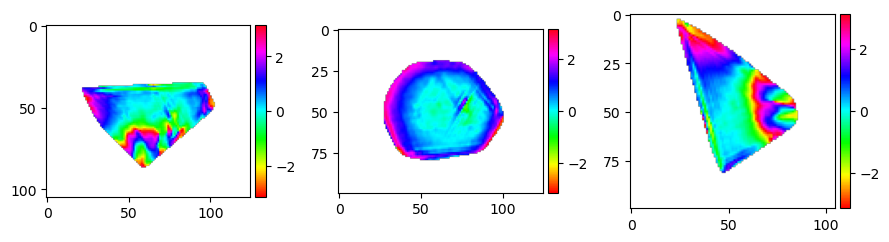

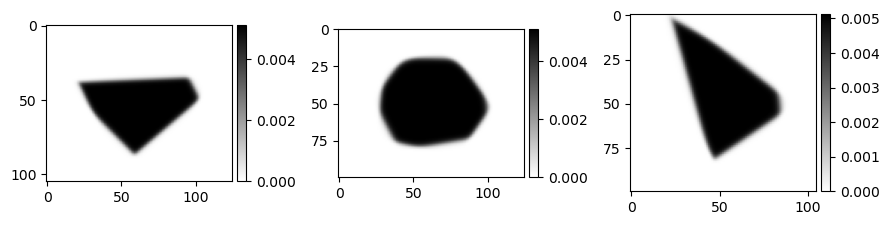

In [26]:
plot_2D_slices_middle_only_phase(obj, unwrap = False)
plot_2D_slices_middle_only_module(obj)

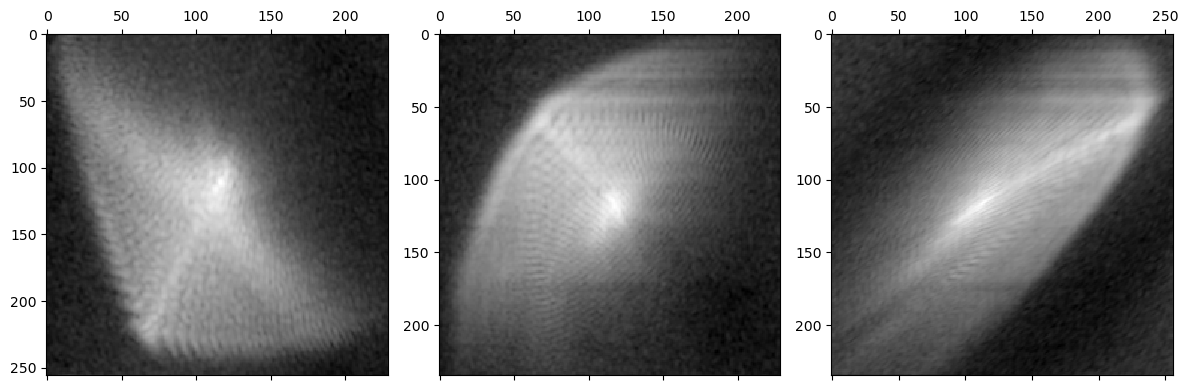

In [20]:
def _center_pad(obj, target_shape):
    pads = []
    for src, dst in zip(obj.shape, target_shape):
        delta = dst - src
        p0 = delta // 2
        p1 = delta - p0
        pads.append((p0, p1))
    return jnp.pad(obj, pads)
obj_p = _center_pad(obj, Iobs.shape)

Icalc = np.abs(ifftshift(fftn(fftshift(obj_p))))
plot_3D_projections(Icalc)

In [ ]:
# np.savez('core_12_JAX_1.npz', obj = obj_p, data = Iobs)